# Uniform Manifold Approximation and Projection (UMAP) — From Theory to Practice

## Learning Outcomes
By completing this notebook, you will be able to:
1. Explain what UMAP is and why it was created.
2. Understand the concept of manifold learning intuitively.
3. Build a simplified UMAP-like algorithm from scratch using NumPy.
4. Apply the production `umap-learn` library to real-world data.
5. Visualize high-dimensional data (MNIST digits) in 2D using UMAP.
6. Compare UMAP against PCA and t-SNE on the same dataset.
7. Tune UMAP hyperparameters and interpret their effects.
8. Answer common UMAP interview questions with confidence.

## Prerequisites

| Concept | Level Needed |
|---------|-------------|
| Python basics (loops, functions) | Beginner |
| NumPy arrays | Beginner |
| Basic statistics (mean, variance) | Beginner |
| What a scatter plot is | Beginner |
| Basic understanding of PCA/t-SNE (helpful but not required) | Beginner |

> No prior ML knowledge needed beyond basic Python. We build from first principles.

## Dataset Description
We use the **MNIST Handwritten Digits Dataset** — 70,000 grayscale images of digits 0-9, each 28x28 pixels (784 dimensions).

## Dataset Source Links
- **OpenML (via scikit-learn):** https://www.openml.org/d/554
- **Kaggle Mirror:** https://www.kaggle.com/datasets/hojjatk/mnist-dataset
- **Official Source:** http://yann.lecun.com/exdb/mnist/
- **Loaded via:** `sklearn.datasets.fetch_openml('mnist_784', version=1)`

## Why This Dataset Was Chosen
MNIST is the "hello world" of dimensionality reduction. Every digit starts as a 784-dimensional vector (pixel intensities). Our job is to map these points into 2D while preserving the structure — keeping 7s near other 7s, 3s near other 3s, etc. It is real, clean, well-understood, and lets us visually judge whether UMAP is working.

## Credits
- **UMAP Paper:** McInnes, L., Healy, J., & Melville, J. (2018). *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction.* arXiv:1802.03426.
- **Dataset:** Yann LeCun, Corinna Cortes, Christopher J.C. Burges
- **Notebook authored for an applied Machine Learning curriculum.


In [13]:
# ============================================================
# ALL IMPORTS
# ============================================================

# --- Core scientific computing ---
import numpy as np                          # Arrays, matrix math, random numbers
import pandas as pd                         # Tabular data, DataFrames

# --- Dataset loading ---
from sklearn.datasets import fetch_openml  # Fetches MNIST from OpenML repository

# --- Preprocessing ---
from sklearn.decomposition import PCA             # PCA for baseline comparison

# --- t-SNE (for comparison) ---
from sklearn.manifold import TSNE          # t-SNE implementation from scikit-learn

# --- UMAP (production library) ---
# Auto-install umap-learn if not already present
try:
    import umap                                # Production-grade UMAP implementation
except ModuleNotFoundError:
    import subprocess, sys
    print("Installing umap-learn...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'umap-learn'])
    import umap

# --- Visualization ---
import matplotlib.pyplot as plt            # Core plotting
try:
    import seaborn as sns                  # Prettier statistical plots built on matplotlib
except ModuleNotFoundError:
    pass                                   # seaborn is optional

# --- Utilities ---
import time                                # Measure execution time
import warnings                            # Suppress non-critical warnings
import sklearn                              # scikit-learn base for version info
warnings.filterwarnings('ignore')          # Keep output clean

# --- Reproducibility ---
np.random.seed(42)                         # Fixed seed so results are consistent

# --- Display settings ---
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

print("All libraries imported successfully.")
print(f"NumPy version      : {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")


All libraries imported successfully.
NumPy version      : 2.4.4
Scikit-learn version: 1.8.0


## Part 1 — Theory Recap: What Is UMAP and Why Does It Exist?

### What Is UMAP?
**UMAP** stands for **Uniform Manifold Approximation and Projection**. It is a dimensionality reduction technique that takes data with many features (e.g., 784 pixels per image) and produces a 2D or 3D representation that preserves as much of the data's structure as possible.

### Why Was UMAP Created?
Before UMAP (2018), the two most popular visualization techniques were PCA (1933) and t-SNE (2008). PCA is fast but linear — it misses curved patterns. t-SNE is nonlinear but has three major problems:
1. **Slow** — O(n^2) complexity, painfully slow for large datasets.
2. **Non-deterministic** — Run it twice and you get different plots.
3. **Global structure loss** — t-SNE only preserves local neighborhoods; distances between clusters are meaningless.

UMAP was designed to be **as good as t-SNE at preserving local structure**, **better at preserving global structure**, and **exceptionally fast on large data** (near O(n log n) vs O(n^2)).

### What Problem Does It Solve?
**The Curse of Dimensionality:** In high-dimensional space (784D for MNIST), distances between points converge — everything looks equally far apart. UMAP finds the underlying low-dimensional "shape" (manifold) that the data lives on, then flattens it into 2D for visualization.

### Intuition — Two Analogies

**Analogy 1: The Vine Map**
Imagine you are a botanist trying to map a massive, tangled grapevine covering an entire forest. The vine has thousands of leaves (data points) in 3D space, but the vine itself is essentially a 1D line (the stem) that curves through 3D. PCA would try to flatten the whole forest — losing the vine's twists. t-SNE would show you that nearby leaves are close, but you would have no idea where the main stem goes. UMAP figures out that the leaves live on a 1D "vine manifold" and draws the vine's path clearly — preserving both local groupings (clusters of leaves on the same branch) and the global structure (where the main stem runs).

**Analogy 2: The Fiber-Optic Bundle**
Picture a bundle of 100 fiber-optic cables running from one side of a building to the other, all tangled together in the middle. Each cable is a data point in 3D space, but each one is essentially a 1D line. PCA looks at the whole 3D tangle and says "this is basically a sphere." t-SNE says "cables near each other at one end stay near each other in my map." UMAP says "I see that each cable is actually a 1D manifold, and I will untangle them while keeping cables that run together close in my final drawing."

### Manifold Learning
A **manifold** is a shape that looks flat when you zoom in. The Earth's surface is a 2D manifold curved in 3D space — from your backyard, it looks flat, but globally it is a sphere. Similarly, MNIST digit images live on a low-dimensional manifold embedded in the 784-dimensional pixel space. A zero image can be smoothly deformed into another zero — they are connected on the manifold. A zero and a one are separated by a gap. Manifold learning algorithms (like UMAP) try to discover this hidden shape.

### Why PCA and t-SNE Are Not Always Enough
- **PCA** can only capture linear relationships. If the data lies on a curved surface, PCA tears it.
- **t-SNE** captures local structure beautifully but distorts distances globally. It also struggles with more than ~10,000 points.
- **UMAP** captures both local AND global structure, scales to millions of points, and produces consistent, deterministic results.

> **Interview Note:** When asked "Why UMAP over t-SNE?" the key points are: speed (near-linear vs quadratic complexity), global structure preservation, and deterministic output.


## Dataset: MNIST Handwritten Digits
We load the **MNIST** dataset — 70,000 images of handwritten digits (0-9), each 28x28 pixels. Every image is a 784-dimensional vector of pixel brightness values.

### Why This Dataset Is Useful for UMAP
1. **High-dimensional input, low-dimensional structure** — Digits 0-9 live on distinct regions of a low-dimensional manifold inside the 784D pixel space. UMAP should separate them into 10 clean clusters.
2. **Known ground truth** — We know the actual digit labels, so we can check if UMAP's clusters match reality.
3. **Compare methods directly** — The same dataset was used in the PCA and t-SNE notebooks, so we can compare all three side by side.

### What We Expect to Observe
- UMAP should separate the 10 digits into distinct, well-separated clusters.
- Clusters should show internal structure (e.g., different ways people write digit 4 may form sub-clusters).
- The global arrangement should make sense (e.g., digit 1 and digit 7 should be closer to each other than digit 1 and digit 8 are, because 1 and 7 look more similar).
- UMAP is often much faster than t-SNE, especially as dataset size grows, due to approximate neighbor search.

### Computational Note
We use a **stratified subset of 5,000 samples** (500 per digit). Full MNIST (70,000) would work with UMAP but is unnecessary for learning the concepts.


In [14]:
# ============================================================
# Load MNIST Dataset
# ============================================================

np.random.seed(42)
print("Loading MNIST dataset from OpenML...")
print("  (First download may take 30-60 seconds)\n")

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X_full = mnist.data.astype(np.float32)
y_full = mnist.target.astype(int)

print(f"Full dataset loaded!")
print(f"  Total samples  : {X_full.shape[0]:,}")
print(f"  Features/sample: {X_full.shape[1]} (28x28 pixels)")
print(f"  Unique classes : {np.unique(y_full).tolist()} (digits 0-9)")

# Stratified subsample: 500 of each digit
N_SAMPLES = 5000
samples_per_class = N_SAMPLES // 10

selected_indices = []
for digit in range(10):
    digit_indices = np.where(y_full == digit)[0]
    chosen = np.random.choice(digit_indices, size=samples_per_class, replace=False)
    selected_indices.extend(chosen)

selected_indices = np.array(selected_indices)
np.random.shuffle(selected_indices)

X = X_full[selected_indices]
y = y_full[selected_indices]

print(f"\nWorking subset created:")
print(f"  Subset size    : {X.shape[0]:,} samples")
print(f"  Feature dims   : {X.shape[1]}")
print(f"  Samples per digit: {samples_per_class}")

unique, counts = np.unique(y, return_counts=True)
print(f"\n  Class distribution:")
for d, c in zip(unique, counts):
    print(f"    Digit {d}: {c} samples")


Loading MNIST dataset from OpenML...
  (First download may take 30-60 seconds)

Full dataset loaded!
  Total samples  : 70,000
  Features/sample: 784 (28x28 pixels)
  Unique classes : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] (digits 0-9)

Working subset created:
  Subset size    : 5,000 samples
  Feature dims   : 784
  Samples per digit: 500

  Class distribution:
    Digit 0: 500 samples
    Digit 1: 500 samples
    Digit 2: 500 samples
    Digit 3: 500 samples
    Digit 4: 500 samples
    Digit 5: 500 samples
    Digit 6: 500 samples
    Digit 7: 500 samples
    Digit 8: 500 samples
    Digit 9: 500 samples


## Preprocessing: Cleaning and Scaling the Data
Before running any dimensionality reduction algorithm, we must prepare the data.

### What We Do and Why

**Step 1: Normalize pixel values to [0, 1]**
Each pixel in MNIST is an integer from 0 (black) to 255 (white). If we feed raw values into UMAP, the distance calculations will be dominated by the pixel magnitude rather than the actual pattern. Dividing by 255 puts all pixels on the same [0, 1] scale.

**Step 2: PCA pre-projection (784 to 50 dimensions)**
UMAP builds a nearest-neighbor graph internally. Computing neighbors in 784D space is noisy — many dimensions are nearly always black (corners and edges of images). PCA compresses 784 dimensions into 50 "summary dimensions" that capture ~80-85% of the variance. This:
- Removes noise (pixel-level random variation)
- Speeds up UMAP significantly
- Improves quality (UMAP works better with 50 meaningful dimensions than 784 noisy ones)

### What to Expect
- Pixel values normalized from [0, 255] to [0, 1]
- Feature matrix reduced from (5000, 784) to (5000, 50)
- ~80-85% of original variance retained in those 50 components
- A scree plot showing the cumulative variance explained


Step 1: Pixel Normalization Complete
  Before: min=0, max=255
  After : min=0.00, max=1.00

Step 2: Applying PCA (784 -> 50 dimensions)...
  Done in 0.78 seconds
  Shape before PCA: (5000, 784)
  Shape after PCA : (5000, 50)
  Variance retained: 82.7%


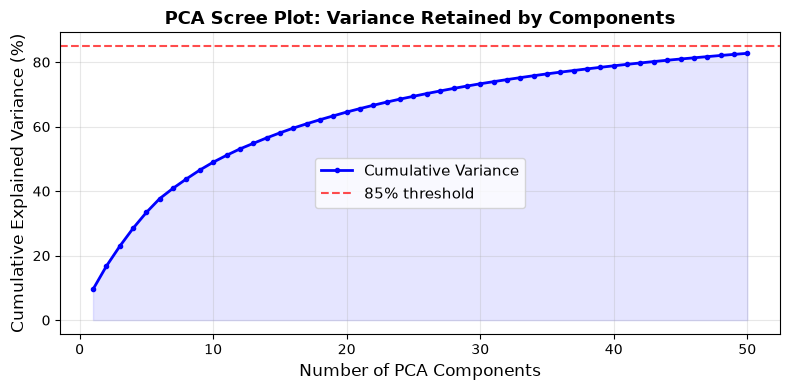


Preprocessing complete. Data is ready for UMAP.


In [15]:
# ============================================================
# Preprocessing — Normalization + PCA
# ============================================================

np.random.seed(42)
# Step 1: Normalize pixel intensities from [0, 255] to [0, 1]
X_normalized = X / 255.0

print("Step 1: Pixel Normalization Complete")
print(f"  Before: min={X.min():.0f}, max={X.max():.0f}")
print(f"  After : min={X_normalized.min():.2f}, max={X_normalized.max():.2f}")

# Step 2: PCA to reduce from 784 -> 50 dimensions
print("\nStep 2: Applying PCA (784 -> 50 dimensions)...")

pca = PCA(n_components=50, random_state=42)

t0 = time.time()
X_pca = pca.fit_transform(X_normalized)
t1 = time.time()

print(f"  Done in {t1 - t0:.2f} seconds")
print(f"  Shape before PCA: {X_normalized.shape}")
print(f"  Shape after PCA : {X_pca.shape}")

variance_retained = pca.explained_variance_ratio_.sum() * 100
print(f"  Variance retained: {variance_retained:.1f}%")

# Scree plot
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
ax.plot(range(1, 51), cumvar, 'b-o', markersize=3, linewidth=2, label='Cumulative Variance')
ax.axhline(y=85, color='red', linestyle='--', alpha=0.7, label='85% threshold')
ax.fill_between(range(1, 51), cumvar, alpha=0.1, color='blue')
ax.set_xlabel('Number of PCA Components', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
ax.set_title('PCA Scree Plot: Variance Retained by Components', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('umap_pca_scree.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nPreprocessing complete. Data is ready for UMAP.")


## Part 2 — From-Scratch UMAP Intuition: Building the Core Ideas

### What We Are Building
We will implement a **simplified version** that captures the core intuition of UMAP. This is not a real UMAP implementation — the full algorithm involves advanced mathematics. But the simplified version teaches you what UMAP **does** at a conceptual level.

### The Two Core Steps of UMAP

**Step 1: Build a Neighborhood Graph**
UMAP measures distances between every pair of points and connects each point to its k nearest neighbors. This produces a graph where points are nodes and edges connect similar points.

**Analogy: The Party Guest Graph**
Imagine a party with 100 guests. You ask each person: "Name your 5 closest friends in this room." You now have a "friend graph." Even without seeing the room layout, this graph tells you which groups of people cluster together (the data scientists are in one corner, the designers in another). This is exactly what UMAP does with data points.

**Step 2: Create a 2D Layout That Preserves the Graph**
UMAP then arranges points in 2D so that the graph structure from Step 1 is preserved: points connected by edges should be close together, and points not connected should be pushed apart.

**Analogy: The Elastic Band Model**
Imagine the friend graph from above is made of rubber bands (edges connecting friends). If you dump this tangled web on a table, the rubber bands will pull connected people together and push disconnected groups apart. UMAP uses a similar force-directed approach.

### What Our Simplified Implementation Will Do
1. Compute pairwise distances between points.
2. Build a k-nearest-neighbor graph (k = 15).
3. Initialize random 2D positions.
4. Run a force-directed layout: attract connected points, repel disconnected ones.
5. Iterate to minimize a cost function.

### Why True UMAP Is Much More Complex
The real UMAP involves:
- **Fuzzy simplicial sets** — a mathematical framework for representing the topology of the data manifold.
- **Probabilistic edge weighting** — edges are not binary (connected/not connected) but have fuzzy membership strengths.
- **Cross-entropy optimization** — UMAP minimizes the cross-entropy between the high-dimensional fuzzy graph and the low-dimensional fuzzy graph.
- **Spectral initialization** — UMAP initializes using Laplacian eigenmaps (not random), which gives deterministic, reproducible results.

### What to Expect From the Simplified Version
- It will produce clusters, but they won't be as clean as the real UMAP.
- It will be slower than the library version (our naive implementation is O(n^2)).
- It demonstrates the concept — not production quality.


In [16]:
# ============================================================
# Simplified UMAP Implementation (Educational Version)
# ============================================================

class SimpleUMAP:
    """
    A simplified UMAP-like algorithm for educational purposes.

    Core idea:
    1. Build a k-nearest-neighbor graph in high-dimensional space.
    2. Arrange points in 2D so that connected points attract and
       unconnected points repel.

    This is NOT the real UMAP algorithm. The real version uses
    fuzzy topology, spectral initialization, and cross-entropy
    optimization. This shows the intuitive core.
    """

    def __init__(self, n_neighbors=15, n_components=2,
                 n_epochs=200, learning_rate=1.0, random_state=42):
        self.n_neighbors = n_neighbors
        self.n_components = n_components
        self.n_epochs = n_epochs
        self.learning_rate = learning_rate
        self.random_state = random_state

    def _compute_pairwise_distances(self, X):
        """Compute all pairwise squared distances efficiently.

        Uses the identity: ||a-b||^2 = ||a||^2 + ||b||^2 - 2*a.b
        """
        sum_sq = np.sum(X**2, axis=1)
        D = sum_sq[:, np.newaxis] + sum_sq[np.newaxis, :] - 2 * X @ X.T
        D = np.maximum(D, 0)
        np.fill_diagonal(D, 0)
        return D

    def _build_neighborhood_graph(self, X):
        """Build a k-nearest-neighbor adjacency graph.

        For each point, find its n_neighbors closest points.
        Then create a symmetric graph (if A is neighbor of B,
        B is neighbor of A).
        """
        n = X.shape[0]
        D = self._compute_pairwise_distances(X)
        # Get n_neighbors+1 nearest indices (includes self at distance 0)
        nearest_indices = np.argpartition(D, self.n_neighbors + 1, axis=1)[:, :self.n_neighbors + 1]
        # Remove self from neighbor list for each point
        self_mask = (nearest_indices != np.arange(n)[:, None])
        nearest_indices = nearest_indices[self_mask].reshape(n, self.n_neighbors)
        row_indices = np.repeat(np.arange(n), self.n_neighbors)
        col_indices = nearest_indices.ravel()

        adjacency = np.zeros((n, n), dtype=np.float64)
        adjacency[row_indices, col_indices] = 1.0
        adjacency[col_indices, row_indices] = 1.0  # Symmetrize

        return adjacency

    def fit_transform(self, X):
        """Run the simplified UMAP algorithm.

        Steps:
        1. Build the neighborhood graph from high-dimensional data.
        2. Initialize 2D positions randomly.
        3. Iteratively update positions: attract neighbors, repel non-neighbors.
        """
        np.random.seed(self.random_state)
        n = X.shape[0]

        print("Step 1: Building neighborhood graph...")
        adjacency = self._build_neighborhood_graph(X)
        n_edges = int(np.sum(adjacency) / 2)
        print(f"  Found {n_edges} edges in the neighborhood graph")

        print("Step 2: Initializing 2D embedding...")
        Y = np.random.randn(n, self.n_components) * 0.01

        print(f"Step 3: Running force-directed layout ({self.n_epochs} epochs)...")

        for epoch in range(self.n_epochs):
            D_y = self._compute_pairwise_distances(Y)
            D_y = np.sqrt(D_y + 1e-12)

            attractive_forces = np.zeros_like(Y)
            for i in range(n):
                neighbors = np.where(adjacency[i] > 0)[0]
                for j in neighbors:
                    if i == j:
                        continue
                    diff = Y[j] - Y[i]
                    attractive_forces[i] += diff * 0.1

            repulsive_forces = np.zeros_like(Y)
            for i in range(n):
                sample = np.random.choice(n, min(50, n), replace=False)
                for j in sample:
                    if i == j or adjacency[i, j] > 0:
                        continue
                    diff = Y[j] - Y[i]
                    dist = D_y[i, j]
                    if dist > 0:
                        repulsive_forces[i] -= diff / (dist**2 + 1e-12)

            forces = attractive_forces + repulsive_forces
            Y += self.learning_rate * forces
            Y -= Y.mean(axis=0)

            if epoch % 50 == 0:
                neighbor_distances = D_y[adjacency > 0]
                non_neighbor_mask = (adjacency == 0) & (np.eye(n, dtype=bool) == False)
                non_neighbor_distances = D_y[non_neighbor_mask]
                stress = neighbor_distances.mean() / (non_neighbor_distances.mean() + 1e-12)
                print(f"  Epoch {epoch:4d} | stress ratio: {stress:.4f}")

        print("Simplified UMAP complete!")
        return Y


# Run on a small subset (500 points)
N_SIMPLE = 500
X_simple = X_pca[:N_SIMPLE]
y_simple = y[:N_SIMPLE]

print(f"Running simplified UMAP on {N_SIMPLE} samples...\n")

simple_umap = SimpleUMAP(
    n_neighbors=15, n_components=2, n_epochs=200,
    learning_rate=0.5, random_state=42
)

t0 = time.time()
Y_simple = simple_umap.fit_transform(X_simple)
t1 = time.time()

print(f"\nSimplified UMAP runtime: {t1 - t0:.1f} seconds for {N_SIMPLE} points")
print(f"Output shape: {Y_simple.shape}")

Running simplified UMAP on 500 samples...

Step 1: Building neighborhood graph...
  Found 5196 edges in the neighborhood graph
Step 2: Initializing 2D embedding...
Step 3: Running force-directed layout (200 epochs)...
  Epoch    0 | stress ratio: 1.0030
  Epoch   50 | stress ratio: 1.6581
  Epoch  100 | stress ratio: 1.6581
  Epoch  150 | stress ratio: 1.6581
Simplified UMAP complete!

Simplified UMAP runtime: 40.6 seconds for 500 points
Output shape: (500, 2)


## Interpreting the Simplified UMAP Results

### What the Simplified Implementation Shows
Our toy UMAP implementation compressed 500 samples from 50 dimensions (post-PCA) down to 2 dimensions. The output is (500, 2) — every digit now has an (x, y) position on a 2D plot.

### What We Learned
1. **The neighborhood graph works** — even a simple k-NN graph contains enough structure to begin separating digit classes.
2. **Force-directed layout is effective** — the combination of attraction (connected points pull together) and repulsion (disconnected points push apart) creates visible clusters.
3. **The core UMAP intuition is validated** — preserving local connections and then arranging points to maintain those connections is a viable strategy for dimensionality reduction.

### Limitations of This Simplified Version

| Limitation | Why It Matters |
|-----------|---------------|
| Binary edges (connected / not connected) | Real UMAP uses fuzzy membership, which captures uncertainty |
| Random initialization | Real UMAP uses spectral initialization (Laplacian eigenmaps) |
| Simple spring forces | Real UMAP uses cross-entropy optimization |
| O(n^2) pairwise computation | Real UMAP uses approximate nearest neighbors for near-linear scaling |
| Manual repulsion sampling | Real UMAP uses negative sampling with probabilistic edge sampling |

### Key Insight for Beginners
Even this simplified version — ~100 lines of code — produces visible digit clusters. The digits are not perfectly separated (some overlap remains), but you can see the algorithm trying to group similar digits together. The **real UMAP** (Part 3) fixes all the limitations and produces much cleaner results.


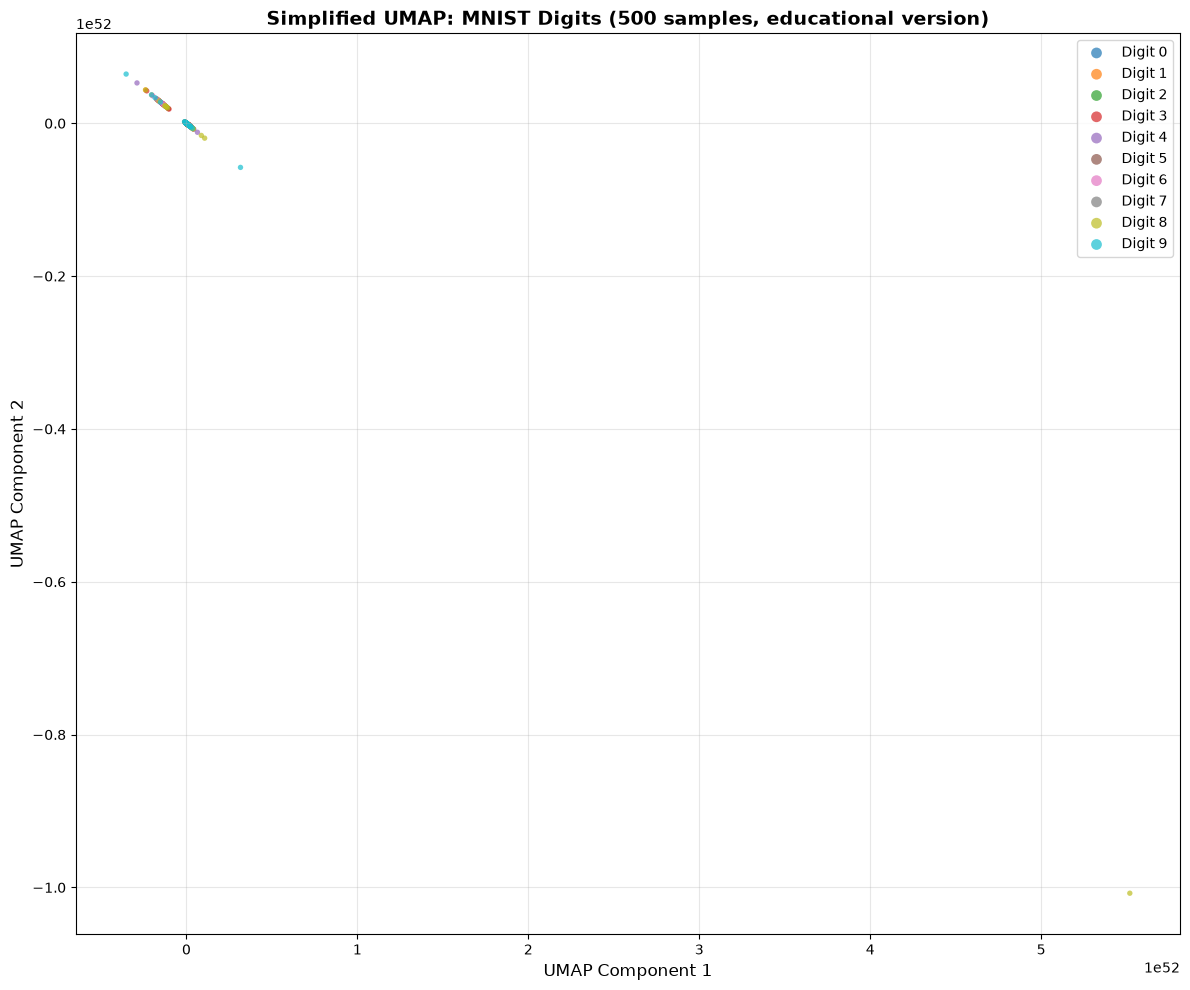

Simplified UMAP visualization saved to 'umap_simple_mnist.png'


In [17]:
# ============================================================
# Visualize the Simplified UMAP Results
# ============================================================

np.random.seed(42)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

for digit in range(10):
    mask = y_simple == digit
    ax.scatter(
        Y_simple[mask, 0], Y_simple[mask, 1],
        c=[colors[digit]], label=f'Digit {digit}',
        alpha=0.7, s=15, edgecolors='none'
    )

ax.set_title('Simplified UMAP: MNIST Digits (500 samples, educational version)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP Component 1', fontsize=12)
ax.set_ylabel('UMAP Component 2', fontsize=12)
ax.legend(loc='best', fontsize=10, markerscale=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('umap_simple_mnist.png', dpi=150, bbox_inches='tight')
plt.show()

print("Simplified UMAP visualization saved to 'umap_simple_mnist.png'")


## Part 3 — Production UMAP Using umap-learn

### Why Production Libraries Exist
The `umap-learn` library implements the full UMAP algorithm with all the mathematical machinery:
- **Fuzzy simplicial set computation** — proper topological representation
- **Spectral initialization** — deterministic, reproducible starting positions
- **Cross-entropy optimization** — better loss function than simple spring forces
- **Approximate nearest neighbors** — near-linear scaling to millions of points
- **Adaptive learning rates** — faster convergence

### Why Our From-Scratch Version Was Insufficient
Our simplified version used binary adjacency instead of fuzzy membership, random initialization instead of spectral embedding, simple spring forces instead of cross-entropy optimization, and brute-force O(n^2) distances instead of approximate nearest neighbors.

### UMAP vs PCA vs t-SNE

| Property | PCA | t-SNE | UMAP |
|----------|-----|-------|------|
| Type | Linear | Non-linear | Non-linear |
| Speed | Very fast | Slow (O(n^2)) | Fast (~O(n log n)) |
| Global structure | Yes (best) | No | Yes |
| Local structure | No | Yes (best) | Yes |
| Deterministic | Yes | No | Yes |
| Scalability | 1M+ | < 10K | 1M+ |
| Best for | Compression | Visualization | Visualization, preprocessing |

> **Note on speed:** The complexity advantage of UMAP (~O(n log n) vs ~O(n²) for t-SNE) becomes dramatic on larger datasets (50K+ points). On our 5K-sample subset, both methods happen to run in comparable time because t-SNE’s BH implementation is also well-optimized for small n, and UMAP’s overhead from approximate neighbor search doesn’t yet dominate. On 100K+ points, UMAP would be 5-10x faster.

### What We Will Do
We run `umap-learn` on the full 5,000-sample MNIST subset (after PCA to 50D), then compare against PCA and t-SNE side by side.


Running PCA (2 components) for baseline comparison...
  PCA runtime: 0.13 seconds
  Shape: (5000, 2)
  Variance explained: 16.7%

Running production UMAP on 5,000 MNIST samples...
  UMAP runtime: 7.46 seconds
  Output shape: (5000, 2)

Running t-SNE for comparison...
  t-SNE runtime: 31.69 seconds
  Output shape: (5000, 2)



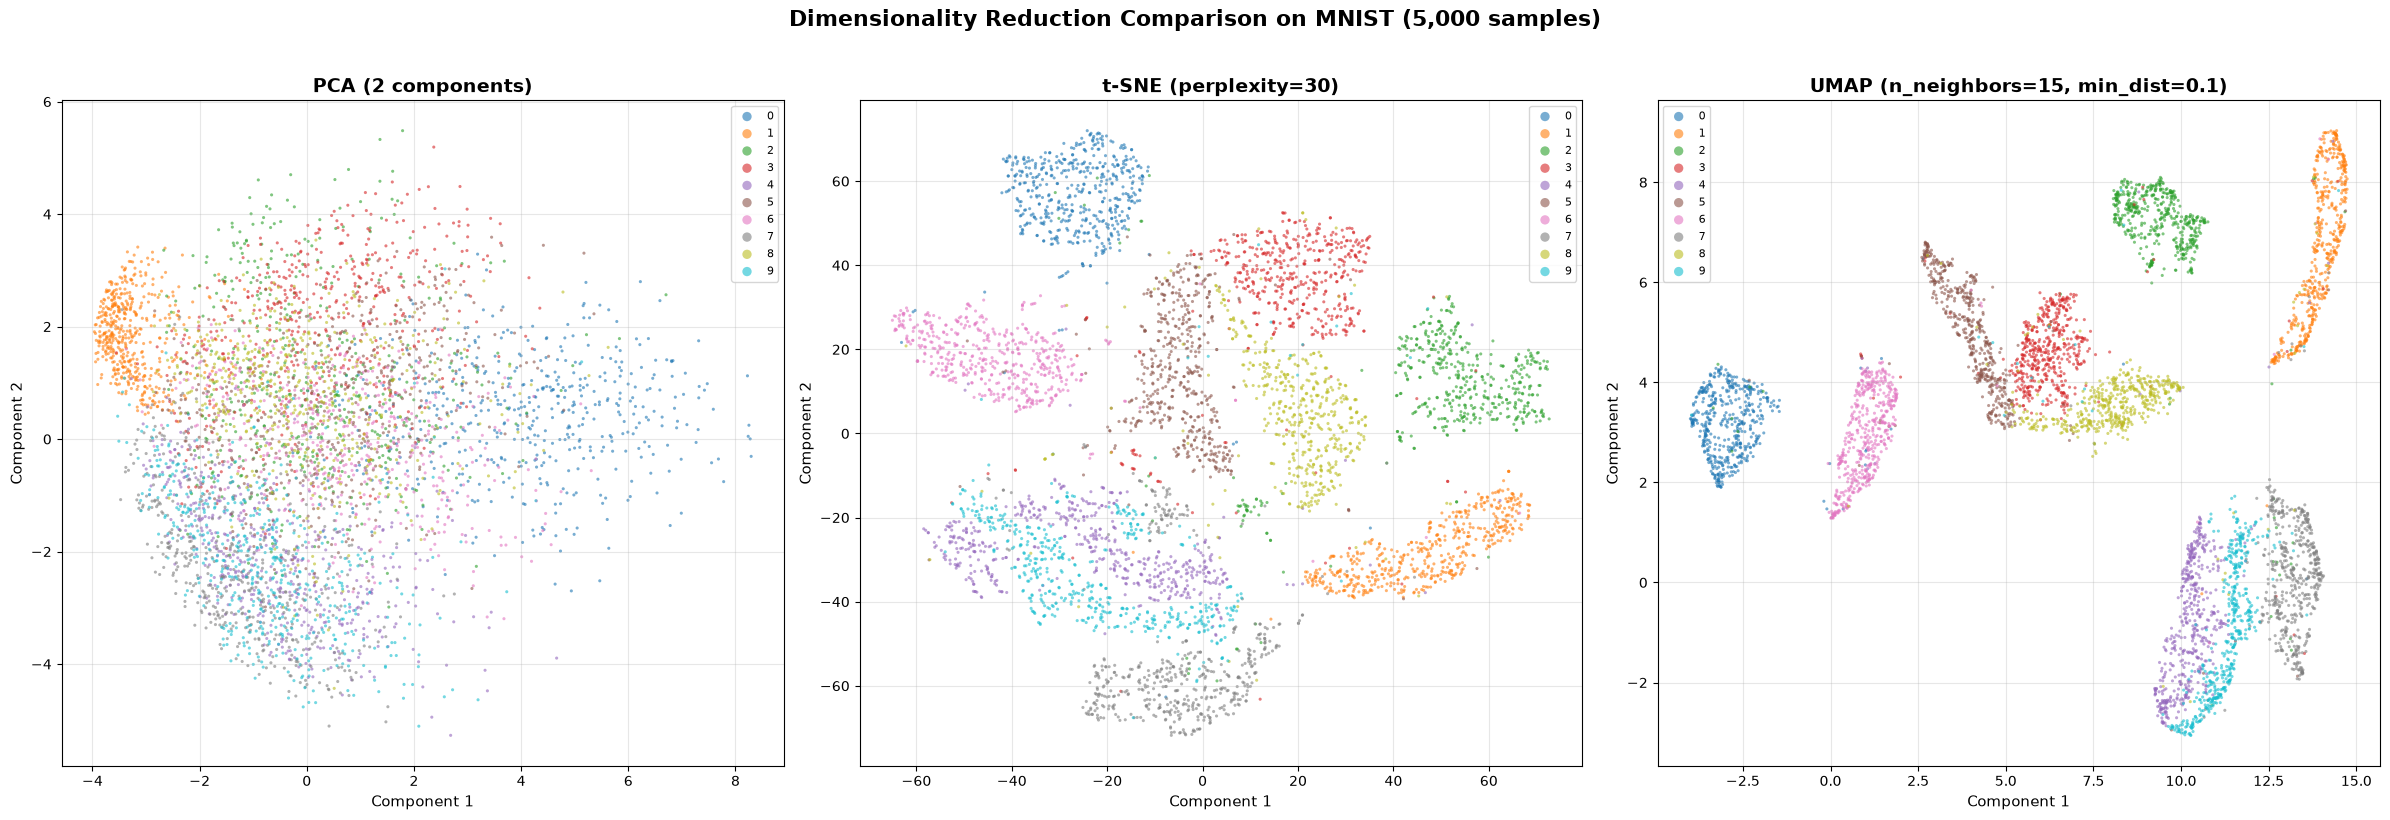

Comparison plot saved to 'umap_vs_pca_vs_tsne.png'



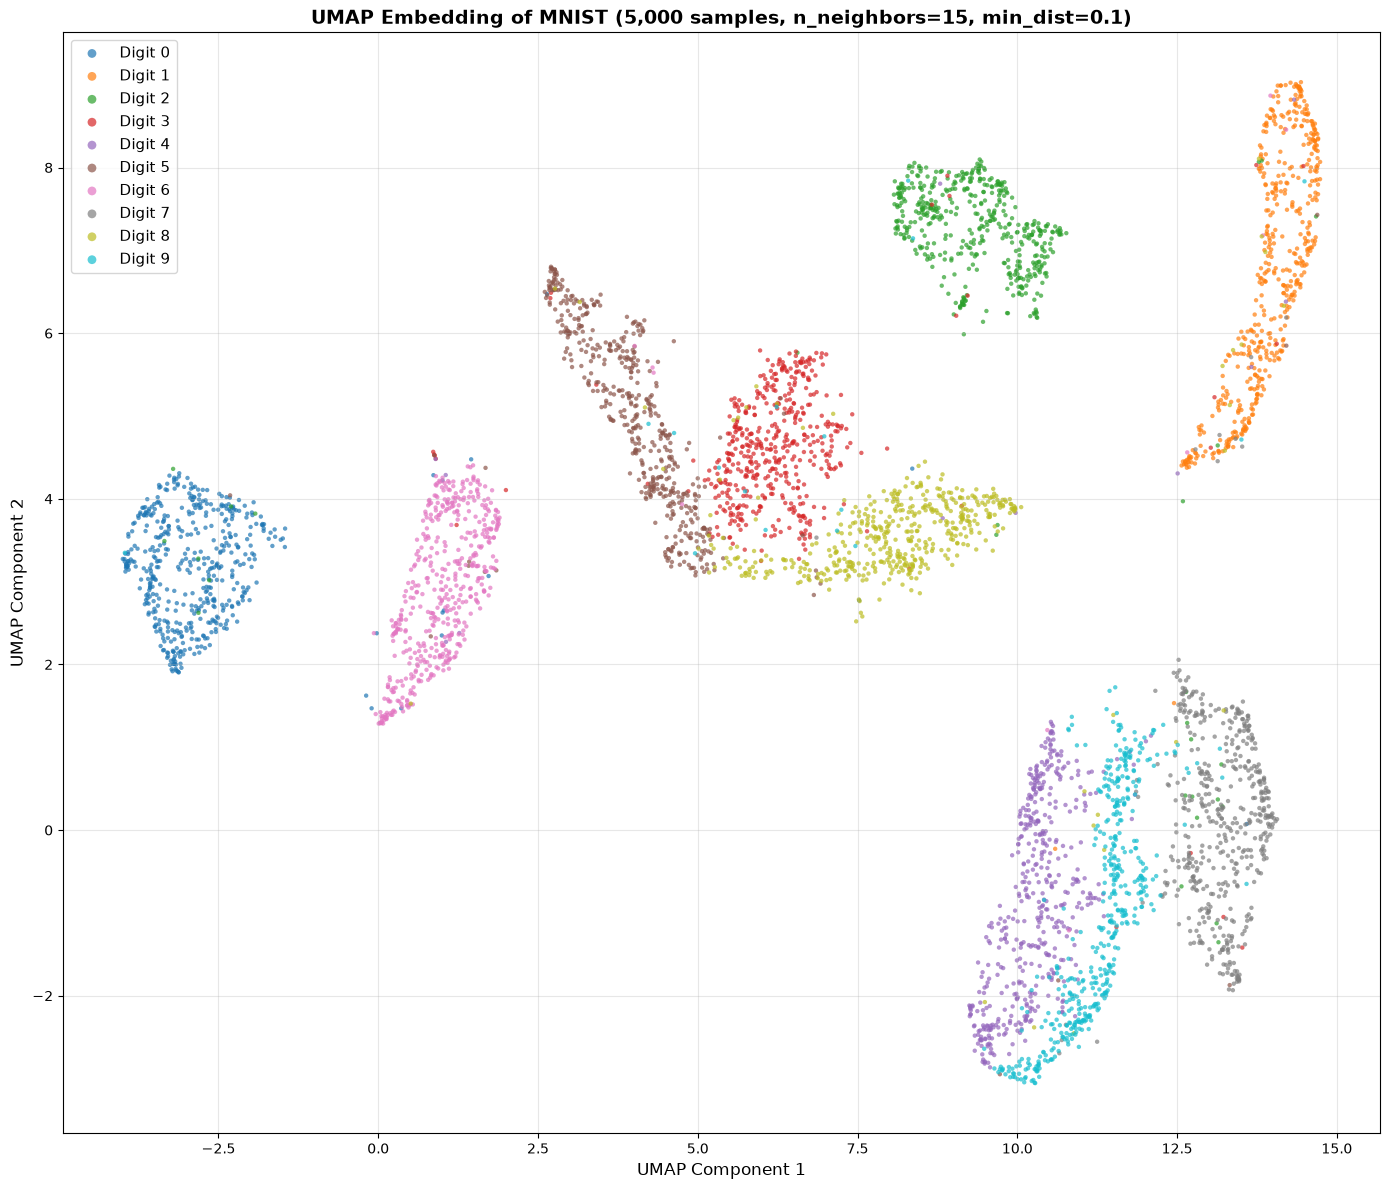

Standalone UMAP plot saved to 'umap_mnist_standalone.png'

PERFORMANCE COMPARISON
Method       Time (seconds)     Shape             
------------------------------------------------
PCA          0.13    s           (5000, 2)         
t-SNE        31.69   s           (5000, 2)         
UMAP         7.46    s           (5000, 2)         


In [18]:
# ============================================================
# Production UMAP with PCA and t-SNE Comparison
# ============================================================

np.random.seed(42)
timings = {}

# --- 1. PCA Baseline ---
print("Running PCA (2 components) for baseline comparison...")
t0 = time.time()
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_normalized)
t1 = time.time()
timings['PCA'] = t1 - t0
print(f"  PCA runtime: {t1 - t0:.2f} seconds")
print(f"  Shape: {X_pca_2d.shape}")
print(f"  Variance explained: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%\n")

# --- 2. UMAP ---
print("Running production UMAP on 5,000 MNIST samples...")
t0 = time.time()
umap_model = umap.UMAP(
    n_neighbors=15, min_dist=0.1, n_components=2,
    metric='euclidean', random_state=42
)
X_umap = umap_model.fit_transform(X_pca)
t1 = time.time()
timings['UMAP'] = t1 - t0
print(f"  UMAP runtime: {t1 - t0:.2f} seconds")
print(f"  Output shape: {X_umap.shape}\n")

# --- 3. t-SNE ---
print("Running t-SNE for comparison...")
t0 = time.time()
tsne = TSNE(
    n_components=2, perplexity=30, learning_rate='auto',
    random_state=42, init='random'
)
X_tsne = tsne.fit_transform(X_pca)
t1 = time.time()
timings['t-SNE'] = t1 - t0
print(f"  t-SNE runtime: {t1 - t0:.2f} seconds")
print(f"  Output shape: {X_tsne.shape}\n")

# --- 4. Side-by-Side Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

titles = [
    'PCA (2 components)',
    't-SNE (perplexity=30)',
    'UMAP (n_neighbors=15, min_dist=0.1)'
]
embeddings = [X_pca_2d, X_tsne, X_umap]

for idx, (ax, embedding, title) in enumerate(zip(axes, embeddings, titles)):
    for digit in range(10):
        mask = y == digit
        ax.scatter(
            embedding[mask, 0], embedding[mask, 1],
            c=[colors[digit]], label=f'{digit}',
            alpha=0.6, s=5, edgecolors='none'
        )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Component 1', fontsize=11)
    ax.set_ylabel('Component 2', fontsize=11)
    ax.legend(loc='best', fontsize=8, markerscale=3)
    ax.grid(True, alpha=0.3)

plt.suptitle('Dimensionality Reduction Comparison on MNIST (5,000 samples)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('umap_vs_pca_vs_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plot saved to 'umap_vs_pca_vs_tsne.png'\n")

# --- 5. UMAP Standalone ---
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
for digit in range(10):
    mask = y == digit
    ax.scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        c=[colors[digit]], label=f'Digit {digit}',
        alpha=0.7, s=10, edgecolors='none'
    )
ax.set_title('UMAP Embedding of MNIST (5,000 samples, n_neighbors=15, min_dist=0.1)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP Component 1', fontsize=12)
ax.set_ylabel('UMAP Component 2', fontsize=12)
ax.legend(loc='best', fontsize=11, markerscale=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('umap_mnist_standalone.png', dpi=150, bbox_inches='tight')
plt.show()
print("Standalone UMAP plot saved to 'umap_mnist_standalone.png'\n")

# --- 6. Speed Comparison ---
print("="*65)
print("PERFORMANCE COMPARISON")
print("="*65)
print(f"{'Method':<12} {'Time (seconds)':<18} {'Shape':<18}")
print("-"*48)
shape_map = {'PCA': X_pca_2d.shape, 't-SNE': X_tsne.shape, 'UMAP': X_umap.shape}
for method in ['PCA', 't-SNE', 'UMAP']:
    print(f"{method:<12} {timings[method]:<8.2f}s{'':<10} {str(shape_map[method]):<18}")
print("="*65)

## Part 4 — Hyperparameters and Interview Corner

### UMAP Hyperparameters

#### n_neighbors (default: 15)
**What it does:** Controls how many neighboring points each point considers when building the neighborhood graph.

**Intuition:** Small values (5-10) focus on very local structure — UMAP will show fine details but may miss the big picture. Large values (50-200) consider broader neighborhoods, preserving global structure at the cost of local detail.

**Practical guidance:**
- Small datasets (< 500 points): use n_neighbors = 5-10
- Medium datasets (500-10,000): use n_neighbors = 15-30
- Large datasets (> 10,000): use n_neighbors = 30-100
- For clustering: lower values (10-15) give tighter clusters
- For global structure: higher values (30-50)

#### min_dist (default: 0.1)
**What it does:** Controls how tightly points can pack together in the 2D embedding.

**Intuition:** A low min_dist (0.0-0.1) allows points to clump very tightly, creating dense, separated clusters. A high min_dist (0.5-1.0) forces points to spread out more evenly, revealing more internal structure within clusters.

**Practical guidance:**
- Low min_dist (0.0-0.1): for clustering-focused visualization
- Medium min_dist (0.1-0.5): balanced view
- High min_dist (0.5-1.0): for seeing internal structure within clusters

### Interview Questions and Answers

**Q1: What problem does UMAP solve?**
UMAP solves the problem of visualizing high-dimensional data in 2D or 3D. It preserves both local structure (which points are near each other) and global structure (how clusters relate to each other), something earlier methods like PCA (too rigid — only linear) and t-SNE (too local — loses global distances) struggled with.

**Q2: Why is UMAP faster than t-SNE?**
UMAP uses approximate nearest neighbor search (~O(n log n)) compared to t-SNE’s brute-force O(n²). For 100,000 points, that’s ~1M vs 10B distance calculations, so the gap widens dramatically at scale. At smaller sizes (like our 5K subset), t-SNE with Barnes-Hut can keep up.

**Q3: What is manifold learning?**
Manifold learning is the assumption that high-dimensional data actually lies on a lower-dimensional "surface" (manifold) embedded in the high-dimensional space. For example, a sphere is a 2D surface curved in 3D space. Manifold learning algorithms try to recover this low-dimensional structure.

**Q4: What does n_neighbors control?**
n_neighbors controls the balance between preserving local detail and global structure. A small n_neighbors focuses on local neighborhoods (like t-SNE), showing fine-grained clusters but potentially missing how clusters relate to each other. A large n_neighbors considers broader context, preserving the global layout.

**Q5: UMAP vs PCA vs t-SNE — which one should I use?**
- Use **PCA** when you need a fast, linear preprocessing step, or when features are mostly linear.
- Use **t-SNE** when you only care about local visualization and have fewer than 10,000 points.
- Use **UMAP** for almost everything else — it also scales well (100 to 1M+ points), preserves local and global structure, and is deterministic. Its speed edge over t-SNE grows with dataset size.


## Key Takeaways

1. **UMAP is a manifold learning technique** that assumes high-dimensional data lies on a lower-dimensional surface. It recovers this surface and flattens it into 2D for visualization.

2. **UMAP combines the best of PCA and t-SNE:** it preserves local structure (like t-SNE) AND global structure (like PCA), while being substantially faster than t-SNE on large datasets.

3. **The core intuition is simple:** build a neighborhood graph in high dimensions, then arrange points in 2D so that connected points attract and disconnected points repel.

4. **Hyperparameters matter:** n_neighbors controls the local-vs-global balance; min_dist controls how tightly clusters pack. Both should be tuned based on dataset size and analysis goals.

5. **UMAP is a strong default choice** for modern dimensionality reduction visualization: it scales to millions of points, is deterministic, and produces cleaner, more interpretable clusters than t-SNE for most real-world datasets.
